# Testes não paramétricos

## Testes para duas amostras independentes

Nestes testes, buscamos comparar duas populações representadas por suas respectivas amostras. Diferente dos testes para duas amostras emparelhadas, aqui não é necessário que as amostras sejam do mesmo tamanho. Dentre os testes para duas amostras independentes, podemos destacar o teste qui-quadrado (para variáveis nominais ou ordinais) e o teste de Mann-Whitney (para variáveis ordinais).

### Teste U de Mann-Whitney

O teste U de Mann-Whitney é aplicado para variáveis quantitativas ou qualitativas em escala ordinal, e visa verificar se duas amostras não pareadas ou independentes são extraídas da mesma população. É uma alternativa ao teste t de Student quando a hipótese de normalidade for violada ou quando o tamanho da amostra for pequeno, podendo ser considerado a versão não
paramétrica do teste t para duas amostras independentes.

Diferente do teste t, que verifica a igualdade das médias de duas populações independentes e com dados contínuos, o teste U de Mann-Whitney testa a igualdade das medianas. Para um teste bilateral, a hipótese nula é de que a mediana das duas populações seja igual, isto é:

$$
\begin{align}
H_0: M_1 = M_2 \\
H_1: M_1 \neq M_2
\end{align}
$$

Exemplo: Visando avaliar a qualidade de duas máquinas, são comparados os diâmetros das peças produzidas (em mm) em cada uma delas, como mostra a base a seguir. Utilize o teste adequado, ao nível de significância de 5%, para testar se as duas amostras provêm ou não de populações com medianas iguais.

In [1]:
import pandas as pd

BASE_DIAMETROS = "./dados/diameters.csv"

df_diametros = pd.read_csv(BASE_DIAMETROS)

df_diametros

,A,B
0,48.50,48.75
1,48.65,48.64
2,48.58,48.80
3,48.55,48.85
4,48.66,48.78
5,48.64,48.79
6,48.50,49.20
7,48.72,NaN


In [2]:
df_diametros.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A       8 non-null      float64
 1   B       7 non-null      float64
dtypes: float64(2)
memory usage: 260.0 bytes


In [3]:
df_diametros.describe()

,A,B
count,8.000000,7.000000
mean,48.600000,48.830000
std,0.080178,0.175499
min,48.500000,48.640000
25%,48.537500,48.765000
50%,48.610000,48.790000
75%,48.652500,48.825000
max,48.720000,49.200000


<Axes: ylabel='Count'>

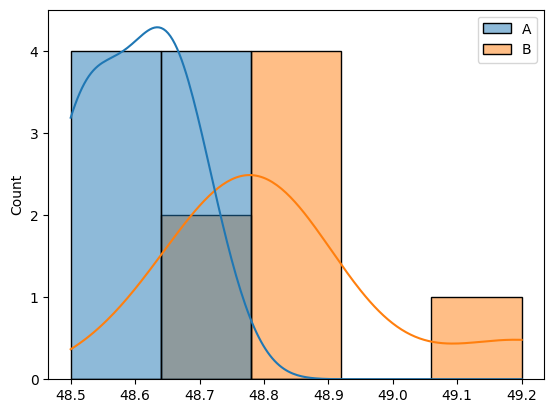

In [4]:
import seaborn as sns

sns.histplot(df_diametros,kde=True)

<Axes: >

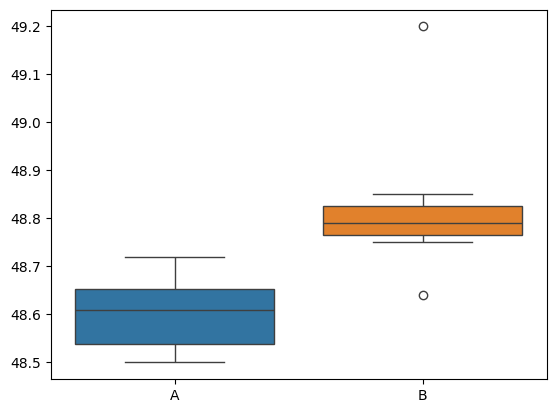

In [5]:
sns.boxplot(data=df_diametros)

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.mannwhitneyu.html

In [6]:
from auxiliares import analises_shapiro_levene

analises_shapiro_levene(df_diametros,center='median')

teste de shapiro
 estatistica_sw =0.930
A segue uma distribuição normal (valor p: 0.520)
 estatistica_sw =0.790
B não segue uma distribuição normal (valor p: 0.032)

teste de levene
estatistica_levene =0.306
Variancia Iguais (valor p: 0.589)


In [7]:
from scipy.stats import mannwhitneyu

mannwhitneyu(df_diametros['A'],df_diametros['B'], nan_policy = "omit")

MannwhitneyuResult(statistic=np.float64(3.5), pvalue=np.float64(0.005395294173421806))

In [8]:
from auxiliares import analise_mannwhitneyu

analise_mannwhitneyu(df_diametros)

teste de mannwhitneyu
estatistica_wilcoxon =3.500
Rejeita a hipótese nula (valor p: 0.005)
